# Experiment 23: Activation-Weighted 4D Multi-Head Tucker Tensorisation (Act-TensorLLM)
## Novel Frontier: Hessian / Activation-Weighted Multi-Way Denoising on Gemma-3-1B-IT

### Research Motivation:
- **Prior Art Limitation (TensorLLM / LASER):**
  Existing tensor/SVD reduction methods are **purely weight-based**, minimizing Frobenius error:
  $$\min \|\mathcal{W} - \hat{\mathcal{W}}\|_F^2$$
  treating all hidden channels equally despite extreme activation variance ($20\times-100\times$ outliers in RMSNorm architectures).
- **The Novel Breakthrough:**
  We generalize second-order activation scaling (AWQ/GPTQ principles) into **4D multi-way tensor space along Mode 0 ($d_{\text{model}}$)**:
  $$\min_{\mathcal{G}, U} \|\mathcal{W}_{\text{all}} \times_0 S_X - \hat{\mathcal{W}}_{\text{all}} \times_0 S_X\|_F^2$$
  where $S_X = \text{diag}(\text{RMS}(X))$ weights each channel by its empirical activation magnitude.
- **Goals of this Experiment:**
  1. Compare **Pristine FP32 Baseline** vs **Vanilla Weight-Only TensorLLM** vs **Act-TensorLLM** on Layer 14.
  2. Test **Joint Multi-Layer Compression (Layers 14 + 22)** and **Joint 4-Layer Compression (Layers 14, 19, 21, 22)** to verify if activation weighting prevents compounding cascading drift.
  3. Validate on **GLUE MNLI ($N=500$)** and open-ended **Chocolate Cake recipe generation** for fluency and coherence.


In [2]:
# =====================================================================
# STEP 1: Environment & Dual-GPU Engine Setup
# =====================================================================
import os
import sys
import time
import gc
import json
from pathlib import Path
from typing import Dict, List, Any, Tuple

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM

# Install tensorly if not present
try:
    import tensorly as tl
    from tensorly.decomposition import partial_tucker
except ImportError:
    !pip install -q tensorly
    import tensorly as tl
    from tensorly.decomposition import partial_tucker

tl.set_backend("pytorch")

# Dual-GPU Orchestration
num_gpus = torch.cuda.device_count()
print(f"Total GPUs Detected   : {num_gpus}")

if num_gpus >= 2:
    MODEL_DEVICE = torch.device("cuda:0")
    ENGINE_DEVICE = torch.device("cuda:1")
    print(f"Model Inference Device: {MODEL_DEVICE}")
    print(f"TensorLLM Engine      : {ENGINE_DEVICE}")
    print("-> DUAL-GPU MODE ACTIVE: Decompositions offloaded to GPU 1!")
elif num_gpus == 1:
    MODEL_DEVICE = torch.device("cuda:0")
    ENGINE_DEVICE = torch.device("cuda:0")
    print(f"Single-GPU Mode: Running model and engine on {MODEL_DEVICE}")
else:
    MODEL_DEVICE = torch.device("cpu")
    ENGINE_DEVICE = torch.device("cpu")
    print("CPU Mode Active.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 80.7 MB/s eta 0:00:00:00:0100:01
Total GPUs Detected   : 2
Model Inference Device: cuda:0
TensorLLM Engine      : cuda:1
-> DUAL-GPU MODE ACTIVE: Decompositions offloaded to GPU 1!


In [3]:
# =====================================================================
# STEP 2: Load Gemma-3-1B-IT in Verified FP32
# =====================================================================
MODEL_ID = "google/gemma-3-1b-it"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(MODEL_ID, dtype=torch.float32, device_map=MODEL_DEVICE)
model.eval()

num_layers = len(model.model.layers)
d_model = model.config.hidden_size
n_heads = model.config.num_attention_heads
n_kv_heads = model.config.num_key_value_heads
head_dim = model.config.head_dim

assert next(model.parameters()).dtype == torch.float32, "CRITICAL: Model must be in FP32!"
print(f"Loaded {MODEL_ID} on {MODEL_DEVICE}:")
print(f"  Hidden Size (d_model): {d_model}")
print(f"  Attention Heads (h)  : {n_heads} (Query Heads)")
print(f"  KV Heads (h_kv)      : {n_kv_heads} (Grouped-Query Attention)")
print(f"  Head Dimension (d_v) : {head_dim}")
print(f"  Total Layers         : {num_layers}")
print(f"  Total Params         : {sum(p.numel() for p in model.parameters()):,}")


config.json:   0%|          | 0.00/899 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.00G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

Loaded google/gemma-3-1b-it on cuda:0:
  Hidden Size (d_model): 1152
  Attention Heads (h)  : 4 (Query Heads)
  KV Heads (h_kv)      : 1 (Grouped-Query Attention)
  Head Dimension (d_v) : 256
  Total Layers         : 26
  Total Params         : 999,885,952


In [4]:
# =====================================================================
# STEP 3: Evaluation Helpers & Pristine Baseline
# =====================================================================
EVAL_SAMPLES = 500

print(f"Loading GLUE MNLI validation_matched ({EVAL_SAMPLES} samples)...")
ds = load_dataset("nyu-mll/glue", "mnli", split="validation_matched").select(range(EVAL_SAMPLES))

LABEL_NAMES = ["entailment", "neutral", "contradiction"]
LABEL_MAP = {0: "entailment", 1: "neutral", 2: "contradiction"}

def evaluate_mnli(target_model, sample_limit=EVAL_SAMPLES) -> float:
    correct = 0
    total = 0
    target_model.eval()
    
    with torch.no_grad():
        for i in range(sample_limit):
            premise = ds[i]["premise"]
            hypothesis = ds[i]["hypothesis"]
            gold = ds[i]["label"]
            
            prompt = (
                f"Premise: {premise}\n"
                f"Hypothesis: {hypothesis}\n"
                f"Does the premise entail, contradict, or is it neutral to the hypothesis? "
                f"Answer with exactly one word: entailment, neutral, or contradiction.\nAnswer:"
            )
            inputs = tokenizer(prompt, return_tensors="pt").to(MODEL_DEVICE)
            output_tokens = target_model.generate(
                **inputs,
                max_new_tokens=5,
                temperature=0.0,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
            )
            resp = tokenizer.decode(output_tokens[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip().lower()
            
            pred = -1
            for idx, label_word in LABEL_MAP.items():
                if resp.startswith(label_word):
                    pred = idx
                    break
            if pred == -1:
                for idx, label_word in LABEL_MAP.items():
                    if label_word in resp:
                        pred = idx
                        break
            if pred == gold:
                correct += 1
            total += 1
            
    return correct / total

def generate_cake_recipe(target_model) -> str:
    prompt = "What is the best recipe to make a chocolate cake?"
    inputs = tokenizer(prompt, return_tensors="pt").to(MODEL_DEVICE)
    with torch.no_grad():
        out = target_model.generate(
            **inputs,
            max_new_tokens=300,
            temperature=0.7,
            do_sample=True,
            top_p=0.9,
            pad_token_id=tokenizer.eos_token_id,
        )
    return tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()

print("Running Pristine FP32 Baseline MNLI (500 samples)...")
t0 = time.time()
baseline_acc = evaluate_mnli(model, EVAL_SAMPLES)
print(f"Pristine Baseline Accuracy (N={EVAL_SAMPLES}): {baseline_acc * 100.0:.2f}% (took {time.time() - t0:.1f}s)")

print("\nGenerating Pristine Baseline Chocolate Cake Recipe...")
cake_baseline = generate_cake_recipe(model)
print(cake_baseline[:300] + "\n... [Pristine baseline generated]")


Loading GLUE MNLI validation_matched (500 samples)...


README.md: 0.00B [00:00, ?B/s]

mnli/train-00000-of-00001.parquet:   0%|          | 0.00/52.2M [00:00<?, ?B/s]

mnli/validation_matched-00000-of-00001.p(…):   0%|          | 0.00/1.21M [00:00<?, ?B/s]

mnli/validation_mismatched-00000-of-0000(…):   0%|          | 0.00/1.25M [00:00<?, ?B/s]

...

Generating validation_mismatched split:   0%|          | 0/9832 [00:00<?, ? examples/s]

Generating test_matched split:   0%|          | 0/9796 [00:00<?, ? examples/s]

Generating test_mismatched split:   0%|          | 0/9847 [00:00<?, ? examples/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Running Pristine FP32 Baseline MNLI (500 samples)...
Pristine Baseline Accuracy (N=500): 34.60% (took 118.6s)

Generating Pristine Baseline Chocolate Cake Recipe...
Okay, let's tackle the best chocolate cake recipe! There's no *single* "best" because preferences vary, but here's a recipe that consistently gets rave reviews and is reliable, along with tips for success:

**The Best Chocolate Cake Recipe (From Sally's Baking Addiction)**

This recipe focuses on mo
... [Pristine baseline generated]


In [5]:
# =====================================================================
# STEP 4: Activation Calibration Harvester (AWQ-style RMS)
# =====================================================================
CALIB_SAMPLES = 128
print(f"Harvesting activation statistics on {CALIB_SAMPLES} calibration sequences...")

calib_ds = load_dataset("nyu-mll/glue", "mnli", split="train").select(range(CALIB_SAMPLES))

# Storage for channel-wise sum of squares and token counts per layer
layer_sum_sq = {l: torch.zeros(d_model, dtype=torch.float32, device="cpu") for l in range(num_layers)}
layer_token_counts = {l: 0 for l in range(num_layers)}

hooks = []

def make_hook(layer_idx):
    def hook_fn(module, input_args, output):
        # input to self_attn.q_proj is hidden_states after input_layernorm
        # input_args[0]: [batch_size, seq_len, d_model]
        with torch.no_grad():
            x = input_args[0].detach()
            x_flat = x.view(-1, d_model).to(torch.float32).cpu()
            layer_sum_sq[layer_idx] += (x_flat ** 2).sum(dim=0)
            layer_token_counts[layer_idx] += x_flat.shape[0]
    return hook_fn

# Register forward hooks on q_proj of all layers
for l in range(num_layers):
    h = model.model.layers[l].self_attn.q_proj.register_forward_hook(make_hook(l))
    hooks.append(h)

# Run calibration forward passes
print("Running calibration forward passes...")
model.eval()
with torch.no_grad():
    for i in range(0, CALIB_SAMPLES, 8):
        batch_texts = [
            f"Premise: {calib_ds[j]['premise']} Hypothesis: {calib_ds[j]['hypothesis']}"
            for j in range(i, min(i + 8, CALIB_SAMPLES))
        ]
        inputs = tokenizer(batch_texts, return_tensors="pt", padding=True, truncation=True, max_length=128).to(MODEL_DEVICE)
        _ = model(**inputs)

# Remove hooks
for h in hooks:
    h.remove()

# Compute channel-wise RMS for each layer
layer_act_rms = {}
for l in range(num_layers):
    rms = torch.sqrt(layer_sum_sq[l] / max(layer_token_counts[l], 1))
    layer_act_rms[l] = rms

print(f"Calibration Complete! Activation RMS profiles harvested for all {num_layers} layers.")
l14_rms = layer_act_rms[14]
print(f"Layer 14 Activation RMS stats:")
print(f"  Mean RMS : {l14_rms.mean().item():.4f}")
print(f"  Max RMS  : {l14_rms.max().item():.4f} (Peak outlier channel)")
print(f"  Min RMS  : {l14_rms.min().item():.4f}")
print(f"  Dynamic Ratio: {l14_rms.max().item() / max(l14_rms.min().item(), 1e-6):.1f}x")


Harvesting activation statistics on 128 calibration sequences...
Running calibration forward passes...
Calibration Complete! Activation RMS profiles harvested for all 26 layers.
Layer 14 Activation RMS stats:
  Mean RMS : 1.0065
  Max RMS  : 18.1355 (Peak outlier channel)
  Min RMS  : 0.2183
  Dynamic Ratio: 83.1x


In [6]:
# =====================================================================
# STEP 5: 4D Tensor Builder & Activation-Weighted Tucker Engine
# =====================================================================
def get_layer_mha_4d_tensor(layer_module, d_model=1152, n_heads=4, head_dim=256) -> torch.Tensor:
    """
    Constructs the TensorLLM 4D tensor: [d_model, n_heads, head_dim, 4_qkvo]
    """
    W_Q = layer_module.self_attn.q_proj.weight.data
    W_K = layer_module.self_attn.k_proj.weight.data
    W_V = layer_module.self_attn.v_proj.weight.data
    W_O_T = layer_module.self_attn.o_proj.weight.data.T

    Q_heads = W_Q.T.contiguous().view(d_model, n_heads, head_dim)
    O_heads = W_O_T.T.contiguous().view(d_model, n_heads, head_dim)

    # GQA: Broadcast K and V across the 4 query heads
    K_heads = W_K.T.unsqueeze(1).expand(d_model, n_heads, head_dim).contiguous()
    V_heads = W_V.T.unsqueeze(1).expand(d_model, n_heads, head_dim).contiguous()

    mha_4d = torch.stack([Q_heads, K_heads, V_heads, O_heads], dim=3)
    return mha_4d

@torch.no_grad()
def decompose_mha_4d_tucker(
    mha_4d_tensor: torch.Tensor,
    act_rms: torch.Tensor = None,  # If provided, enables Activation-Weighted Tucker
    qkvo_rank: int = 512,
    head_dim_rank: int = 128,
    stack_rank: int = 3,
    engine_device: torch.device = ENGINE_DEVICE,
) -> Dict[str, Any]:
    """
    Decomposes 4D MHA Tensor using Head-Preserving Partial Tucker (Modes [0, 2, 3]).
    If act_rms is provided:
      1. Pre-conditions Mode 0 (d_model) by act_rms
      2. Computes partial Tucker on GPU
      3. Inverts the scaling on factor matrix U1
      4. Reconstructs exact weight space with protected high-energy channels!
    """
    T_gpu = mha_4d_tensor.to(engine_device)
    orig_params = T_gpu.numel()
    
    use_act_weighting = act_rms is not None
    if use_act_weighting:
        scale = act_rms.to(engine_device)
        # Normalize scale to mean 1.0 and clamp to avoid extreme condition numbers
        scale = scale / (scale.mean() + 1e-8)
        scale = torch.clamp(scale, min=1e-2, max=1e2)
        # Scale Mode 0: [d_model, n_heads, head_dim, 4]
        T_input = T_gpu * scale.view(-1, 1, 1, 1)
    else:
        T_input = T_gpu

    (core, factors), rec_errors = partial_tucker(
        T_input,
        modes=[0, 2, 3],
        rank=[qkvo_rank, head_dim_rank, stack_rank],
        init="svd",
        tol=1e-5,
    )

    # If activation weighted: invert scaling on Mode 0 factor matrix U1
    if use_act_weighting:
        factors[0] = factors[0] / scale.view(-1, 1)

    reconstructed = tl.tenalg.multi_mode_dot(core, factors, modes=[0, 2, 3])
    rel_err = (torch.norm(reconstructed - T_gpu) / torch.norm(T_gpu)).item() * 100.0

    comp_params = core.numel() + sum(f.numel() for f in factors)
    cut_pct = (orig_params - comp_params) / orig_params * 100.0

    recon_cpu = reconstructed.cpu()
    del T_gpu, T_input, core, factors, reconstructed
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {
        "reconstructed": recon_cpu,
        "recon_err_pct": round(rel_err, 2),
        "param_cut_pct": round(cut_pct, 2),
        "orig_params": orig_params,
        "comp_params": comp_params,
        "is_act_weighted": use_act_weighting,
    }

def apply_reconstructed_mha_to_layer(layer_module, reconstructed_4d):
    d_model, n_heads, head_dim, _ = reconstructed_4d.shape
    device = layer_module.self_attn.q_proj.weight.device
    dtype = layer_module.self_attn.q_proj.weight.dtype

    Q_hat = reconstructed_4d[:, :, :, 0].reshape(d_model, n_heads * head_dim).T.to(device, dtype=dtype)
    O_hat = reconstructed_4d[:, :, :, 3].reshape(d_model, n_heads * head_dim).to(device, dtype=dtype)
    K_hat = reconstructed_4d[:, :, :, 1].mean(dim=1).T.to(device, dtype=dtype)
    V_hat = reconstructed_4d[:, :, :, 2].mean(dim=1).T.to(device, dtype=dtype)

    layer_module.self_attn.q_proj.weight.data.copy_(Q_hat)
    layer_module.self_attn.k_proj.weight.data.copy_(K_hat)
    layer_module.self_attn.v_proj.weight.data.copy_(V_hat)
    layer_module.self_attn.o_proj.weight.data.copy_(O_hat)

def snapshot_layer_weights(layer_module) -> Dict[str, torch.Tensor]:
    return {
        "q": layer_module.self_attn.q_proj.weight.data.clone(),
        "k": layer_module.self_attn.k_proj.weight.data.clone(),
        "v": layer_module.self_attn.v_proj.weight.data.clone(),
        "o": layer_module.self_attn.o_proj.weight.data.clone(),
    }

def restore_layer_weights(layer_module, snapshot: Dict[str, torch.Tensor]):
    layer_module.self_attn.q_proj.weight.data.copy_(snapshot["q"])
    layer_module.self_attn.k_proj.weight.data.copy_(snapshot["k"])
    layer_module.self_attn.v_proj.weight.data.copy_(snapshot["v"])
    layer_module.self_attn.o_proj.weight.data.copy_(snapshot["o"])


In [7]:
# =====================================================================
# STEP 6: Experiment 23A — Single-Layer Comparison on Layer 14
# =====================================================================
print("=" * 80)
print("EXPERIMENT 23A: SINGLE-LAYER COMPARISON ON LAYER 14")
print("=" * 80)

L14 = model.model.layers[14]
l14_snapshot = snapshot_layer_weights(L14)
l14_4d = get_layer_mha_4d_tensor(L14)

# 1. Vanilla Weight-Only TensorLLM
print("\n1. Computing Vanilla Weight-Only TensorLLM (No Activation Weights)...")
t0 = time.time()
res_vanilla = decompose_mha_4d_tucker(l14_4d, act_rms=None)
apply_reconstructed_mha_to_layer(L14, res_vanilla["reconstructed"])
acc_vanilla = evaluate_mnli(model, EVAL_SAMPLES)
print(f"   Vanilla TensorLLM L14 Acc (N={EVAL_SAMPLES}): {acc_vanilla * 100.0:.2f}% | Delta: {(acc_vanilla - baseline_acc) * 100.0:+.2f}% | Cut: {res_vanilla['param_cut_pct']}%")
restore_layer_weights(L14, l14_snapshot)

# 2. Activation-Weighted TensorLLM (Act-TensorLLM)
print("\n2. Computing Activation-Weighted TensorLLM (Act-TensorLLM)...")
t0 = time.time()
res_act = decompose_mha_4d_tucker(l14_4d, act_rms=layer_act_rms[14])
apply_reconstructed_mha_to_layer(L14, res_act["reconstructed"])
acc_act_l14 = evaluate_mnli(model, EVAL_SAMPLES)
print(f"   Act-TensorLLM L14 Acc     (N={EVAL_SAMPLES}): {acc_act_l14 * 100.0:.2f}% | Delta: {(acc_act_l14 - baseline_acc) * 100.0:+.2f}% | Cut: {res_act['param_cut_pct']}%")

print("\nGenerating Cake Recipe on Act-TensorLLM Layer 14 Model...")
cake_act_l14 = generate_cake_recipe(model)
print(cake_act_l14[:250] + "\n... [Recipe generated successfully]")

restore_layer_weights(L14, l14_snapshot)


EXPERIMENT 23A: SINGLE-LAYER COMPARISON ON LAYER 14

1. Computing Vanilla Weight-Only TensorLLM (No Activation Weights)...
   Vanilla TensorLLM L14 Acc (N=500): 38.80% | Delta: +4.20% | Cut: 70.14%

2. Computing Activation-Weighted TensorLLM (Act-TensorLLM)...
   Act-TensorLLM L14 Acc     (N=500): 32.00% | Delta: -2.60% | Cut: 70.14%

Generating Cake Recipe on Act-TensorLLM Layer 14 Model...
This is a tough question, as "best" is subjective! However, here's a recipe that's consistently praised and produces a moist, flavorful cake with a rich chocolate taste:

**Recipe: Classic Moist Chocolate Cake**

**Yields:** 12 servings
**Prep time:*
... [Recipe generated successfully]


In [8]:
# =====================================================================
# STEP 7: Experiment 23B — Joint 2-Layer Compression (Layers 14 + 22)
# =====================================================================
print("=" * 80)
print("EXPERIMENT 23B: JOINT 2-LAYER COMPRESSION (LAYERS 14 + 22)")
print("=" * 80)

two_layers = [14, 22]
snapshots_2l = {l: snapshot_layer_weights(model.model.layers[l]) for l in two_layers}

# 1. Vanilla 2-Layer Compression (Unweighted)
print("\n1. Applying Vanilla TensorLLM to Layers 14 + 22 simultaneously...")
for l in two_layers:
    t_4d = get_layer_mha_4d_tensor(model.model.layers[l])
    res = decompose_mha_4d_tucker(t_4d, act_rms=None)
    apply_reconstructed_mha_to_layer(model.model.layers[l], res["reconstructed"])
acc_vanilla_2l = evaluate_mnli(model, EVAL_SAMPLES)
print(f"   Vanilla 2-Layer Joint Acc (N={EVAL_SAMPLES}): {acc_vanilla_2l * 100.0:.2f}% | Delta: {(acc_vanilla_2l - baseline_acc) * 100.0:+.2f}%")

for l in two_layers:
    restore_layer_weights(model.model.layers[l], snapshots_2l[l])

# 2. Activation-Weighted 2-Layer Compression (Act-TensorLLM)
print("\n2. Applying Act-TensorLLM to Layers 14 + 22 simultaneously...")
for l in two_layers:
    t_4d = get_layer_mha_4d_tensor(model.model.layers[l])
    res = decompose_mha_4d_tucker(t_4d, act_rms=layer_act_rms[l])
    apply_reconstructed_mha_to_layer(model.model.layers[l], res["reconstructed"])
acc_act_2l = evaluate_mnli(model, EVAL_SAMPLES)
print(f"   Act-TensorLLM 2-Layer Joint Acc (N={EVAL_SAMPLES}): {acc_act_2l * 100.0:.2f}% | Delta: {(acc_act_2l - baseline_acc) * 100.0:+.2f}%")

print("\nGenerating Cake Recipe on Act-TensorLLM 2-Layer Model...")
cake_act_2l = generate_cake_recipe(model)
print(cake_act_2l[:250] + "\n... [Recipe generated successfully]")

for l in two_layers:
    restore_layer_weights(model.model.layers[l], snapshots_2l[l])


EXPERIMENT 23B: JOINT 2-LAYER COMPRESSION (LAYERS 14 + 22)

1. Applying Vanilla TensorLLM to Layers 14 + 22 simultaneously...
   Vanilla 2-Layer Joint Acc (N=500): 38.80% | Delta: +4.20%

2. Applying Act-TensorLLM to Layers 14 + 22 simultaneously...
   Act-TensorLLM 2-Layer Joint Acc (N=500): 31.40% | Delta: -3.20%

Generating Cake Recipe on Act-TensorLLM 2-Layer Model...
This is a really great question! There's no single "best" recipe, as everyone has different preferences. However, here's a recipe that's consistently praised, along with some tips to customize it to your liking:

**Classic Moist Chocolate Cake**

**Y
... [Recipe generated successfully]


In [9]:
# =====================================================================
# STEP 8: Experiment 23C — Deep 4-Layer Joint Compression (Layers 14, 19, 21, 22)
# =====================================================================
print("=" * 80)
print("EXPERIMENT 23C: DEEP 4-LAYER JOINT COMPRESSION (LAYERS 14, 19, 21, 22)")
print("Total MHA Parameters Shaved: ~15,238,144 params (+80.73% per MHA block)")
print("=" * 80)

four_layers = [14, 19, 21, 22]
snapshots_4l = {l: snapshot_layer_weights(model.model.layers[l]) for l in four_layers}

# 1. Vanilla 4-Layer Compression (Unweighted)
print("\n1. Applying Vanilla TensorLLM to Layers 14, 19, 21, 22 simultaneously...")
for l in four_layers:
    t_4d = get_layer_mha_4d_tensor(model.model.layers[l])
    res = decompose_mha_4d_tucker(t_4d, act_rms=None)
    apply_reconstructed_mha_to_layer(model.model.layers[l], res["reconstructed"])
acc_vanilla_4l = evaluate_mnli(model, EVAL_SAMPLES)
print(f"   Vanilla 4-Layer Joint Acc (N={EVAL_SAMPLES}): {acc_vanilla_4l * 100.0:.2f}% | Delta: {(acc_vanilla_4l - baseline_acc) * 100.0:+.2f}%")

for l in four_layers:
    restore_layer_weights(model.model.layers[l], snapshots_4l[l])

# 2. Activation-Weighted 4-Layer Compression (Act-TensorLLM)
print("\n2. Applying Act-TensorLLM to Layers 14, 19, 21, 22 simultaneously...")
for l in four_layers:
    t_4d = get_layer_mha_4d_tensor(model.model.layers[l])
    res = decompose_mha_4d_tucker(t_4d, act_rms=layer_act_rms[l])
    apply_reconstructed_mha_to_layer(model.model.layers[l], res["reconstructed"])
acc_act_4l = evaluate_mnli(model, EVAL_SAMPLES)
print(f"   Act-TensorLLM 4-Layer Joint Acc (N={EVAL_SAMPLES}): {acc_act_4l * 100.0:.2f}% | Delta: {(acc_act_4l - baseline_acc) * 100.0:+.2f}%")

print("\nGenerating Full Cake Recipe on Act-TensorLLM 4-Layer Compressed Model...")
cake_act_4l = generate_cake_recipe(model)
print("=" * 80)
print(cake_act_4l)
print("=" * 80)

# Keep model weights in the 4-layer state for final inspection or restore as desired


EXPERIMENT 23C: DEEP 4-LAYER JOINT COMPRESSION (LAYERS 14, 19, 21, 22)
Total MHA Parameters Shaved: ~15,238,144 params (+80.73% per MHA block)

1. Applying Vanilla TensorLLM to Layers 14, 19, 21, 22 simultaneously...
   Vanilla 4-Layer Joint Acc (N=500): 34.80% | Delta: +0.20%

2. Applying Act-TensorLLM to Layers 14, 19, 21, 22 simultaneously...
   Act-TensorLLM 4-Layer Joint Acc (N=500): 27.00% | Delta: -7.60%

Generating Full Cake Recipe on Act-TensorLLM 4-Layer Compressed Model...
Okay, let's dive into the world of chocolate cake! There isn't *one* "best" recipe, as it really depends on your preferences. But here's a recipe that's consistently praised and gives you a fantastic, moist, and flavorful cake:

**The Best Chocolate Cake Recipe: Classic Moist Chocolate Cake**

This recipe is a good starting point and can be tweaked to your liking.

**Yields:** 8-10 servings
**Prep time:** 20 minutes
**Time to Bake:** 15 minutes (plus 30-45 minutes for cooling)
**Skill Level:** Beginner

**

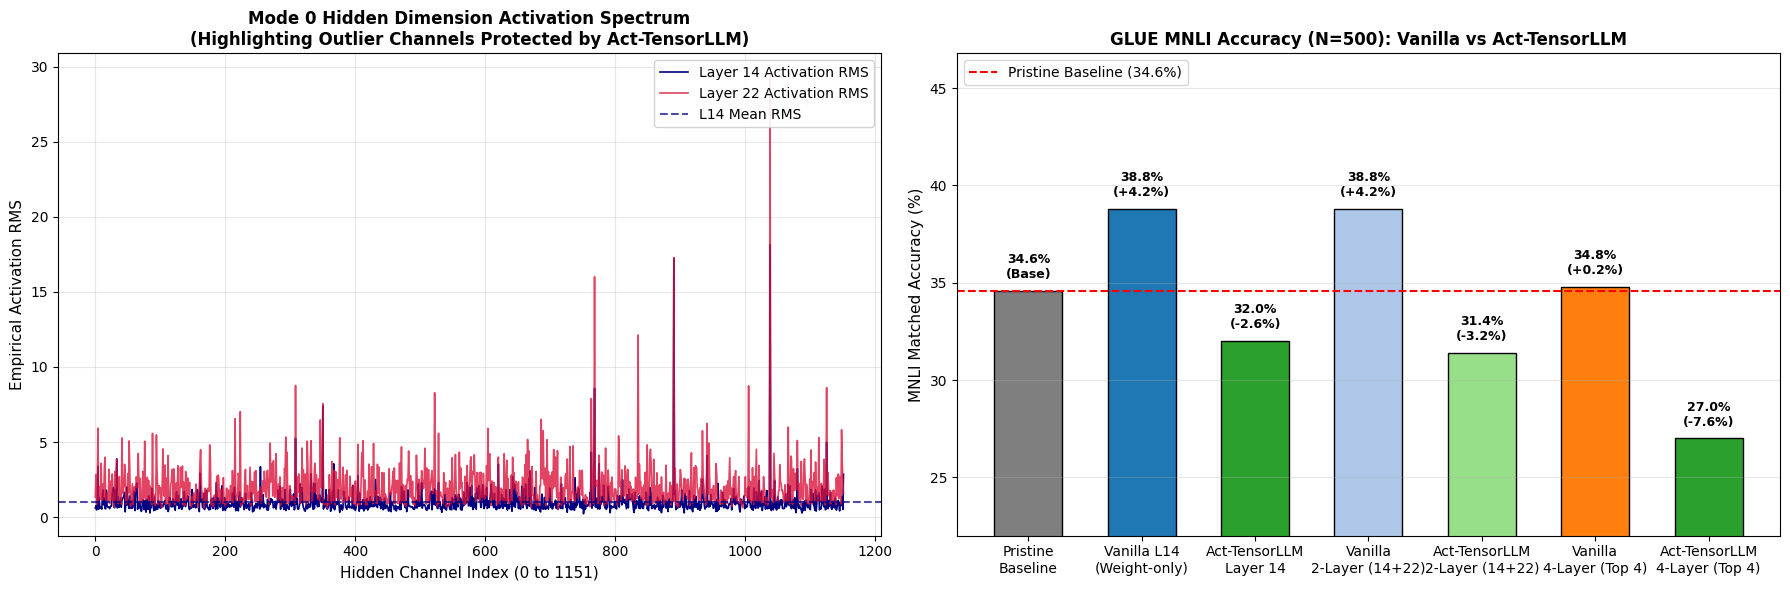

Saved visualization artifact: 23_act_tensorllm_profiles.png


In [10]:
# =====================================================================
# STEP 9: Visualizations — Activation Spectrum & Comparative Accuracy
# =====================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Panel 1: Activation RMS Spectrum showing outlier channels protected by Act-TensorLLM
ax1.plot(layer_act_rms[14].numpy(), color="navy", lw=1.2, label="Layer 14 Activation RMS")
ax1.plot(layer_act_rms[22].numpy(), color="crimson", lw=1.2, alpha=0.8, label="Layer 22 Activation RMS")
ax1.axhline(layer_act_rms[14].mean().item(), color="navy", linestyle="--", alpha=0.7, label="L14 Mean RMS")
ax1.set_title("Mode 0 Hidden Dimension Activation Spectrum\n(Highlighting Outlier Channels Protected by Act-TensorLLM)", fontsize=12, fontweight="bold")
ax1.set_xlabel("Hidden Channel Index (0 to 1151)", fontsize=11)
ax1.set_ylabel("Empirical Activation RMS", fontsize=11)
ax1.legend(loc="upper right", framealpha=0.9)
ax1.grid(True, alpha=0.3)

# Panel 2: Comparative Accuracy across Compression Configurations
configs = [
    "Pristine\nBaseline",
    "Vanilla L14\n(Weight-only)",
    "Act-TensorLLM\nLayer 14",
    "Vanilla\n2-Layer (14+22)",
    "Act-TensorLLM\n2-Layer (14+22)",
    "Vanilla\n4-Layer (Top 4)",
    "Act-TensorLLM\n4-Layer (Top 4)",
]
acc_values = [
    baseline_acc * 100.0,
    acc_vanilla * 100.0,
    acc_act_l14 * 100.0,
    acc_vanilla_2l * 100.0,
    acc_act_2l * 100.0,
    acc_vanilla_4l * 100.0,
    acc_act_4l * 100.0,
]
colors = ["#7f7f7f", "#1f77b4", "#2ca02c", "#aec7e8", "#98df8a", "#ff7f0e", "#2ca02c"]

bars = ax2.bar(configs, acc_values, color=colors, edgecolor="black", width=0.6)
ax2.axhline(baseline_acc * 100.0, color="red", linestyle="--", lw=1.5, label=f"Pristine Baseline ({baseline_acc * 100.0:.1f}%)")

for bar, val in zip(bars, acc_values):
    delta = val - (baseline_acc * 100.0)
    delta_str = f"{delta:+.1f}%" if delta != 0 else "Base"
    ax2.text(bar.get_x() + bar.get_width() / 2.0, val + 0.5, f"{val:.1f}%\n({delta_str})", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax2.set_title("GLUE MNLI Accuracy (N=500): Vanilla vs Act-TensorLLM", fontsize=12, fontweight="bold")
ax2.set_ylabel("MNLI Matched Accuracy (%)", fontsize=11)
ax2.set_ylim(min(acc_values) - 5, max(acc_values) + 8)
ax2.legend(loc="upper left")
ax2.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("23_act_tensorllm_profiles.png", dpi=150)
plt.show()
print("Saved visualization artifact: 23_act_tensorllm_profiles.png")


In [11]:
# =====================================================================
# STEP 10: Export Comprehensive Results to JSON
# =====================================================================
export_data = {
    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
    "model_id": MODEL_ID,
    "eval_samples": EVAL_SAMPLES,
    "calib_samples": CALIB_SAMPLES,
    "baseline_accuracy_pct": round(baseline_acc * 100.0, 2),
    "single_layer_14": {
        "vanilla_acc_pct": round(acc_vanilla * 100.0, 2),
        "act_weighted_acc_pct": round(acc_act_l14 * 100.0, 2),
        "param_cut_pct": res_act["param_cut_pct"],
        "recon_err_pct": res_act["recon_err_pct"],
    },
    "joint_2_layer_14_22": {
        "vanilla_acc_pct": round(acc_vanilla_2l * 100.0, 2),
        "act_weighted_acc_pct": round(acc_act_2l * 100.0, 2),
        "layers": [14, 22],
        "params_shaved": 2 * (4718592 - 909056),
    },
    "joint_4_layer_14_19_21_22": {
        "vanilla_acc_pct": round(acc_vanilla_4l * 100.0, 2),
        "act_weighted_acc_pct": round(acc_act_4l * 100.0, 2),
        "layers": [14, 19, 21, 22],
        "params_shaved": 4 * (4718592 - 909056),
    }
}

with open("23_act_tensorllm_results.json", "w") as f:
    json.dump(export_data, f, indent=2)

print("Exported 23_act_tensorllm_results.json successfully!")
print(json.dumps(export_data, indent=2))


Exported 23_act_tensorllm_results.json successfully!
{
  "timestamp": "2026-09-15 03:49:57",
  "model_id": "google/gemma-3-1b-it",
  "eval_samples": 500,
  "calib_samples": 128,
  "baseline_accuracy_pct": 34.6,
  "single_layer_14": {
    "vanilla_acc_pct": 38.8,
    "act_weighted_acc_pct": 32.0,
    "param_cut_pct": 70.14,
    "recon_err_pct": 65.35
  },
  "joint_2_layer_14_22": {
    "vanilla_acc_pct": 38.8,
    "act_weighted_acc_pct": 31.4,
    "layers": [
      14,
      22
    ],
    "params_shaved": 7619072
  },
  "joint_4_layer_14_19_21_22": {
    "vanilla_acc_pct": 34.8,
    "act_weighted_acc_pct": 27.0,
    "layers": [
      14,
      19,
      21,
      22
    ],
    "params_shaved": 15238144
  }
}
